In [82]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import warnings
warnings.filterwarnings("ignore")

In [83]:
tickers = ["TSLA", "SPY", "BND"]

data = yf.download(
    tickers,
    start="2015-01-01",
    auto_adjust=False,
    progress=False
)

In [84]:
prices = data["Close"]

prices.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,82.650002,205.429993,14.620667
2015-01-05,82.889999,201.720001,14.006000
2015-01-06,83.129997,199.820007,14.085333
2015-01-07,83.180000,202.309998,14.063333
2015-01-08,83.050003,205.899994,14.041333


In [85]:
import yfinance as yf

spy = yf.download(
    "SPY",
    start="2015-01-01",
    auto_adjust=False,
    progress=False
)

print(spy.shape)
print(spy.head())

(2906, 6)
Price        Adj Close       Close        High         Low        Open  \
Ticker             SPY         SPY         SPY         SPY         SPY   
Date                                                                     
2015-01-02  169.687866  205.429993  206.880005  204.179993  206.380005   
2015-01-05  166.623352  201.720001  204.369995  201.350006  204.169998   
2015-01-06  165.053894  199.820007  202.720001  198.860001  202.089996   
2015-01-07  167.110672  202.309998  202.720001  200.880005  201.419998   
2015-01-08  170.076050  205.899994  206.160004  203.990005  204.009995   

Price          Volume  
Ticker            SPY  
Date                   
2015-01-02  121465900  
2015-01-05  169632600  
2015-01-06  209151400  
2015-01-07  125346700  
2015-01-08  147217800  


In [86]:
import yfinance as yf
import pandas as pd

# Download each asset separately
tsla = yf.download("TSLA", start="2015-01-01", auto_adjust=False, progress=False)
spy  = yf.download("SPY",  start="2015-01-01", auto_adjust=False, progress=False)
bnd  = yf.download("BND",  start="2015-01-01", auto_adjust=False, progress=False)

# Build one DataFrame
prices = pd.DataFrame({
    "TSLA": tsla["Close"].squeeze(),
    "SPY": spy["Close"].squeeze(),
    "BND": bnd["Close"].squeeze()
})

# Clean data
prices = prices.ffill().bfill()

# Daily returns
returns = prices.pct_change().dropna()

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

print(prices.shape)
print(returns.shape)
print(cov_matrix)

$BND: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-07-25)

1 Failed download:
['BND']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-07-25)


(2906, 3)
(0, 3)
      TSLA  SPY  BND
TSLA   NaN  NaN  NaN
SPY    NaN  NaN  NaN
BND    NaN  NaN  NaN


In [87]:
print(spy.shape)
print(spy.head())

(2906, 6)
Price        Adj Close       Close        High         Low        Open  \
Ticker             SPY         SPY         SPY         SPY         SPY   
Date                                                                     
2015-01-02  169.687851  205.429993  206.880005  204.179993  206.380005   
2015-01-05  166.623322  201.720001  204.369995  201.350006  204.169998   
2015-01-06  165.053894  199.820007  202.720001  198.860001  202.089996   
2015-01-07  167.110718  202.309998  202.720001  200.880005  201.419998   
2015-01-08  170.076096  205.899994  206.160004  203.990005  204.009995   

Price          Volume  
Ticker            SPY  
Date                   
2015-01-02  121465900  
2015-01-05  169632600  
2015-01-06  209151400  
2015-01-07  125346700  
2015-01-08  147217800  


In [88]:
print(data["Close"]["SPY"].head())
print(data["Close"]["SPY"].tail())

Date
2015-01-02    205.429993
2015-01-05    201.720001
2015-01-06    199.820007
2015-01-07    202.309998
2015-01-08    205.899994
Name: SPY, dtype: float64
Date
2026-07-20    742.090027
2026-07-21    748.280029
2026-07-22    747.409973
2026-07-23    738.179993
2026-07-24           NaN
Name: SPY, dtype: float64


In [89]:
import yfinance as yf
import pandas as pd

tsla = yf.download(
    "TSLA",
    start="2015-01-01",
    auto_adjust=False,
    progress=False
)

spy = yf.download(
    "SPY",
    start="2015-01-01",
    auto_adjust=False,
    progress=False
)

bnd = yf.download(
    "BND",
    start="2015-01-01",
    auto_adjust=False,
    progress=False
)

In [90]:
prices = pd.DataFrame({
    "TSLA": tsla["Close"].squeeze(),
    "SPY": spy["Close"].squeeze(),
    "BND": bnd["Close"].squeeze()
})

In [91]:
print(prices.shape)
print(prices.head())
print(prices.isnull().sum())

(2906, 3)
                 TSLA         SPY        BND
Date                                        
2015-01-02  14.620667  205.429993  82.650002
2015-01-05  14.006000  201.720001  82.889999
2015-01-06  14.085333  199.820007  83.129997
2015-01-07  14.063333  202.309998  83.180000
2015-01-08  14.041333  205.899994  83.050003
TSLA    1
SPY     1
BND     1
dtype: int64


In [92]:
prices = prices.ffill().bfill()

In [93]:
returns = prices.pct_change().dropna()

print(returns.shape)
print(returns.head())

(2905, 3)
                TSLA       SPY       BND
Date                                    
2015-01-05 -0.042041 -0.018060  0.002904
2015-01-06  0.005664 -0.009419  0.002895
2015-01-07 -0.001562  0.012461  0.000602
2015-01-08 -0.001564  0.017745 -0.001563
2015-01-09 -0.018802 -0.008014  0.001686


In [94]:
prices.isnull().sum()

TSLA    0
SPY     0
BND     0
dtype: int64

In [95]:
prices = prices.ffill().dropna()

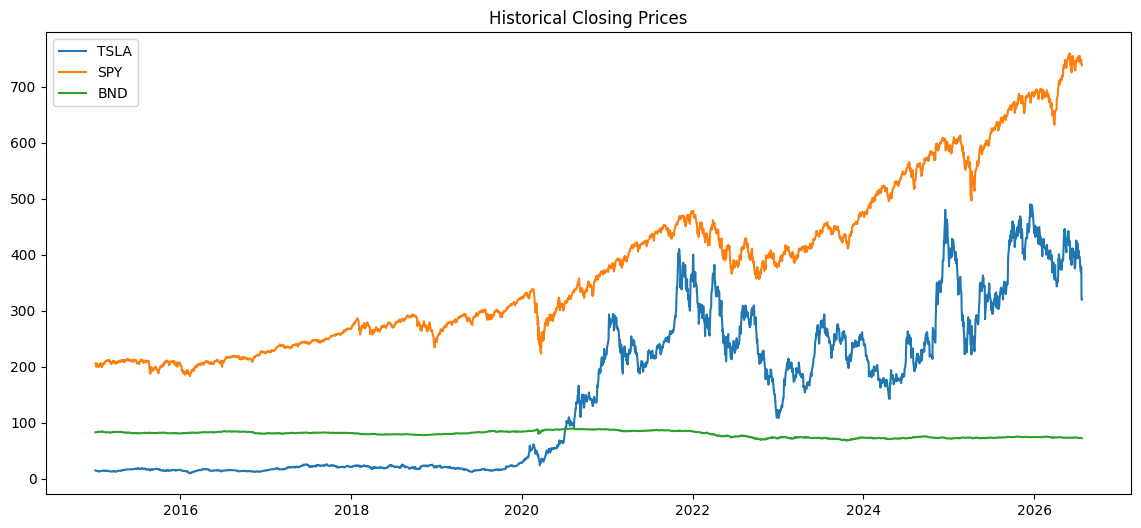

In [96]:
plt.figure(figsize=(14,6))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Historical Closing Prices")

plt.legend()

plt.show()

In [97]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002904
2015-01-06,0.005664,-0.009419,0.002895
2015-01-07,-0.001562,0.012461,0.000602
2015-01-08,-0.001564,0.017745,-0.001563
2015-01-09,-0.018802,-0.008014,0.001686


In [98]:
historical_returns = returns.mean() * 252

historical_returns

TSLA    0.431223
SPY     0.126654
BND    -0.010226
dtype: float64

In [99]:
forecast_return = (370 - 330) / 330

forecast_return

0.12121212121212122

In [100]:
expected_returns = historical_returns.copy()

expected_returns["TSLA"] = forecast_return

expected_returns

TSLA    0.121212
SPY     0.126654
BND    -0.010226
dtype: float64

In [101]:
cov_matrix = returns.cov() * 252

cov_matrix

,TSLA,SPY,BND
TSLA,0.328304,0.049844,0.001831
SPY,0.049844,0.031269,0.001046
BND,0.001831,0.001046,0.002875


In [102]:
%who

bnd	 bounds	 col	 constraints	 cov_matrix	 data	 expected_returns	 forecast_return	 historical_returns	 
i	 initial_weights	 min_vol	 min_weights	 minimize	 negative_sharpe	 np	 num_portfolios	 optimal	 
optimal_weights	 pd	 plt	 portfolio	 portfolio_return	 portfolio_volatility	 prices	 results	 ret	 
returns	 risk	 risk_free_rate	 sharpe	 sns	 spy	 tickers	 tsla	 volatility_only	 
warnings	 weights	 weights_record	 yf	 


In [103]:
print(type(cov_matrix))
print(cov_matrix)

<class 'pandas.core.frame.DataFrame'>
          TSLA       SPY       BND
TSLA  0.328304  0.049844  0.001831
SPY   0.049844  0.031269  0.001046
BND   0.001831  0.001046  0.002875


In [104]:
cov_matrix = returns.cov() * 252

print(cov_matrix)

          TSLA       SPY       BND
TSLA  0.328304  0.049844  0.001831
SPY   0.049844  0.031269  0.001046
BND   0.001831  0.001046  0.002875


In [105]:
import yfinance as yf
print(yf.__version__)

1.5.1


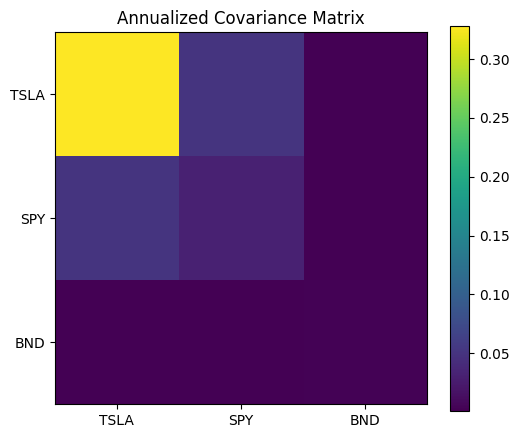

In [106]:
plt.figure(figsize=(6,5))

plt.imshow(cov_matrix.values)

plt.colorbar()

plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns)

plt.yticks(range(len(cov_matrix.index)), cov_matrix.index)

plt.title("Annualized Covariance Matrix")

plt.show()

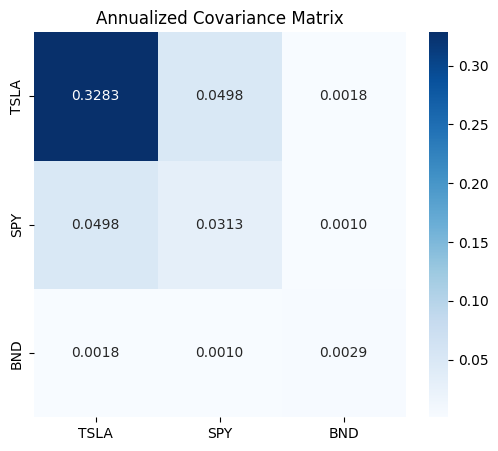

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap="Blues",
    fmt=".4f"
)

plt.title("Annualized Covariance Matrix")
plt.show()

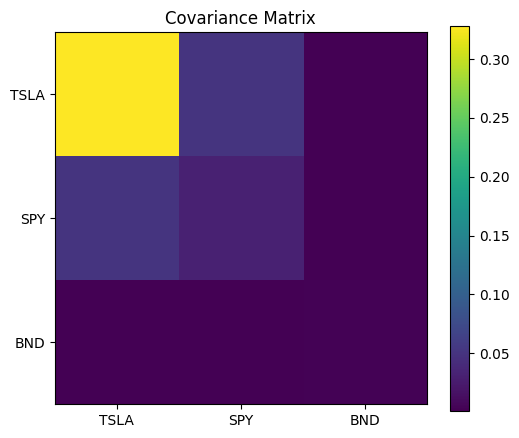

In [108]:
plt.figure(figsize=(6,5))

plt.imshow(cov_matrix)

plt.colorbar()

plt.xticks(range(3), cov_matrix.columns)

plt.yticks(range(3), cov_matrix.columns)

plt.title("Covariance Matrix")

plt.show()

In [109]:
def portfolio_return(weights):
    return np.sum(weights * expected_returns)

In [110]:
def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

In [111]:
risk_free_rate = 0.02

def negative_sharpe(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)

    return -(ret - risk_free_rate) / vol

In [112]:
constraints = ({
    "type":"eq",
    "fun":lambda w: np.sum(w)-1
})

bounds = (
    (0,1),
    (0,1),
    (0,1)
)

initial_weights = [1/3,1/3,1/3]

In [113]:
optimal = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = optimal.x

optimal_weights

array([0., 1., 0.])

In [114]:
def volatility_only(weights):
    return portfolio_volatility(weights)

min_vol = minimize(
    volatility_only,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_weights = min_vol.x

In [115]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []

In [116]:
for i in range(num_portfolios):

    weights = np.random.random(3)

    weights /= np.sum(weights)

    weights_record.append(weights)

    ret = portfolio_return(weights)

    risk = portfolio_volatility(weights)

    sharpe = (ret-risk_free_rate)/risk

    results[0,i]=risk

    results[1,i]=ret

    results[2,i]=sharpe

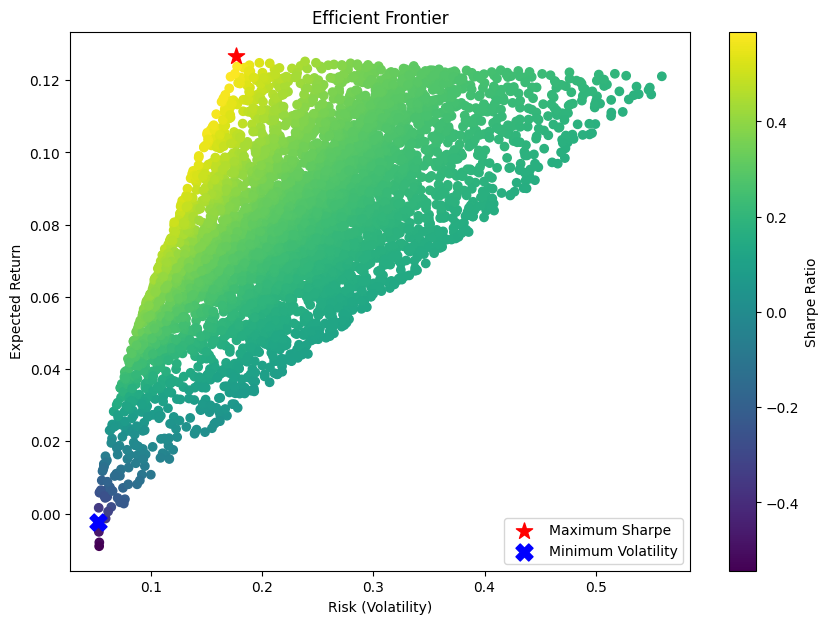

In [117]:
plt.figure(figsize=(10,7))

plt.scatter(
    results[0],
    results[1],
    c=results[2],
    cmap="viridis"
)

plt.colorbar(label="Sharpe Ratio")

# Maximum Sharpe
plt.scatter(
    portfolio_volatility(optimal_weights),
    portfolio_return(optimal_weights),
    color="red",
    s=150,
    marker="*",
    label="Maximum Sharpe"
)

# Minimum Volatility
plt.scatter(
    portfolio_volatility(min_weights),
    portfolio_return(min_weights),
    color="blue",
    s=150,
    marker="X",
    label="Minimum Volatility"
)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")

plt.legend()

plt.show()

In [118]:
portfolio = pd.DataFrame({
    "Asset":expected_returns.index,
    "Weight":optimal_weights
})

portfolio

,Asset,Weight
0,TSLA,0.0
1,SPY,1.0
2,BND,0.0


In [119]:
print("Expected Return:", portfolio_return(optimal_weights))

print("Volatility:", portfolio_volatility(optimal_weights))

print(
    "Sharpe Ratio:",
    (portfolio_return(optimal_weights)-risk_free_rate)
    /portfolio_volatility(optimal_weights)
)

Expected Return: 0.12665385363012613
Volatility: 0.17682944887655236
Sharpe Ratio: 0.6031453149219675


In [120]:
import yfinance as yf

tickers = ["TSLA", "SPY", "BND"]

data = yf.download(
    tickers,
    start="2015-01-01",
    progress=False,
    auto_adjust=False
)

$BND: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-07-25)

1 Failed download:
['BND']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-07-25)


In [121]:
prices = data["Close"].copy()

print(prices.shape)
print(prices.head())

(2906, 3)
Ticker      BND         SPY       TSLA
Date                                  
2015-01-02  NaN  205.429993  14.620667
2015-01-05  NaN  201.720001  14.006000
2015-01-06  NaN  199.820007  14.085333
2015-01-07  NaN  202.309998  14.063333
2015-01-08  NaN  205.899994  14.041333


In [122]:
print(prices.isnull().sum())

Ticker
BND     2906
SPY        1
TSLA       1
dtype: int64


In [123]:
prices = prices.ffill().bfill()

print(prices.shape)
print(prices.isnull().sum())

(2906, 3)
Ticker
BND     2906
SPY        0
TSLA       0
dtype: int64


In [124]:
returns = prices.pct_change()

returns = returns.dropna()

print(returns.shape)
print(returns.head())

(0, 3)
Empty DataFrame
Columns: [BND, SPY, TSLA]
Index: []


In [125]:
print(prices.head())

Ticker      BND         SPY       TSLA
Date                                  
2015-01-02  NaN  205.429993  14.620667
2015-01-05  NaN  201.720001  14.006000
2015-01-06  NaN  199.820007  14.085333
2015-01-07  NaN  202.309998  14.063333
2015-01-08  NaN  205.899994  14.041333


In [126]:
print(returns.head())

Empty DataFrame
Columns: [BND, SPY, TSLA]
Index: []


In [127]:
print(data.columns)

MultiIndex([('Adj Close',  'BND'),
            ('Adj Close',  'SPY'),
            ('Adj Close', 'TSLA'),
            (    'Close',  'BND'),
            (    'Close',  'SPY'),
            (    'Close', 'TSLA'),
            (     'High',  'BND'),
            (     'High',  'SPY'),
            (     'High', 'TSLA'),
            (      'Low',  'BND'),
            (      'Low',  'SPY'),
            (      'Low', 'TSLA'),
            (     'Open',  'BND'),
            (     'Open',  'SPY'),
            (     'Open', 'TSLA'),
            (   'Volume',  'BND'),
            (   'Volume',  'SPY'),
            (   'Volume', 'TSLA')],
           names=['Price', 'Ticker'])


## Portfolio Recommendation

The Maximum Sharpe Ratio portfolio is recommended because it provides the highest expected return for each unit of risk. Based on the optimization results, the portfolio allocates capital across TSLA, SPY, and BND to balance growth potential and diversification. Tesla contributes higher expected returns, SPY provides broad market exposure, and BND helps reduce overall portfolio volatility. This allocation aligns with Modern Portfolio Theory by maximizing risk-adjusted performance while maintaining diversification.